<a href="https://colab.research.google.com/github/202318/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1: Download and upload the Airplane Crashes Dataset from Kaggle.


In [14]:
from google.colab import files
uploaded = files.upload()

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908 (1).csv


Question 2: Determine the number of rows and columns in the dataset.

In [15]:
import pandas as pd
import glob

csv_file = glob.glob("*.csv")[0]
df = pd.read_csv(csv_file)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5268
Number of columns: 13


Question 3: Display the last 75 rows in the dataset.

In [16]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [17]:
last_75 = df.tail(75)
print("Number of rows displayed:", len(last_75))

Number of rows displayed: 75


Question 4: Identify missing data in each column and determine the most appropriate method for treating it.

In [18]:
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


**Treatment of Missing Values**

**Date**: No treatment is required because there are no missing values.

**Time:** Replace missing values with "Unknown". There are many missing values, so deleting the affected rows would result in significant loss of data.

**Location**: Replace missing values with "Unknown" because location is categorical data and the actual locations cannot be accurately estimated.

**Operator**: Replace missing values with "Unknown" because the aircraft operator cannot reliably be predicted from the other data.

**Flight** #: Replace missing values with "Unknown". Since 4,199 values are missing, deleting these records would remove most of the dataset.

**Route**: Replace missing values with "Unknown" because routes cannot be accurately estimated, and deleting 1,707 records would cause substantial data loss.

**Type**: Replace missing values with "Unknown" because aircraft type is categorical information and should not be guessed.

**Registration**: Replace missing values with "Unknown". Registration numbers are aircraft identifiers, so using another aircraft's registration, such as the mode, would be inappropriate.

**cn/In**: Replace missing values with "Unknown" because these are aircraft identification details that cannot be reliably estimated.

**Aboard**: Leave the missing values as NaN and exclude those records when performing calculations involving the number aboard. Replacing them with zero would incorrectly imply that nobody was aboard.

**Fatalities**: Leave the missing values as NaN and exclude them from calculations requiring fatalities. They should not be replaced with zero because zero specifically represents a crash with no fatalities.

**Ground**: Leave missing values as NaN when performing calculations involving ground fatalities rather than assuming that a missing value means zero.

Question 5: Create a new dataframe from the raw/uncleaned data called fatality_locations with the columns Date, Location, Aboard and Fatalities.

In [19]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

fatality_locations

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0
...,...,...,...,...
5263,05/20/2009,"Near Madiun, Indonesia",112.0,98.0
5264,05/26/2009,"Near Isiro, DemocratiRepubliCongo",4.0,4.0
5265,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",228.0,228.0
5266,06/07/2009,"Near Port Hope Simpson, Newfoundland, Canada",1.0,1.0


Question 6: Determine the date of the highest number of recorded fatalities from the fatality_locations dataframe.

In [20]:
highest_fatalities = fatality_locations.loc[
    fatality_locations['Fatalities'].idxmax()
]

highest_fatalities

,2963
Date,03/27/1977
Location,"Tenerife, Canary Islands"
Aboard,644.0
Fatalities,583.0


Conclusion: The highest number of recorded fatalities was 583, recorded on 03/27/1977 in Tenerife, Canary Islands.

Question 7: Compare the number of passengers aboard to the number of fatalities per crash. Are there any recorded crashes where there were no fatalities? If so, how many?

In [21]:
zero_fatality_crashes = fatality_locations[
    fatality_locations['Fatalities'] == 0
]

print("Number of crashes with no fatalities:", len(zero_fatality_crashes))

zero_fatality_crashes

Number of crashes with no fatalities: 58


,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0


Question 8: Split the Location column into two columns containing Region and State/Country.

In [22]:
fatality_locations[['Region', 'State/Country']] = (
    fatality_locations['Location']
    .str.rsplit(',', n=1, expand=True)
)

fatality_locations

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany
...,...,...,...,...,...,...
5263,05/20/2009,"Near Madiun, Indonesia",112.0,98.0,Near Madiun,Indonesia
5264,05/26/2009,"Near Isiro, DemocratiRepubliCongo",4.0,4.0,Near Isiro,DemocratiRepubliCongo
5265,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",228.0,228.0,"AtlantiOcean, 570 miles northeast of Natal",Brazil
5266,06/07/2009,"Near Port Hope Simpson, Newfoundland, Canada",1.0,1.0,"Near Port Hope Simpson, Newfoundland",Canada


Question 9: Order the dataframe by the number of fatalities from highest to lowest and select the first 100.

In [23]:
top_100_fatalities = fatality_locations.sort_values(
    by='Fatalities',
    ascending=False
).head(100)

top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


Question 10: Generate a pie chart showing the distribution of the top 25 fatalities per Country/U.S. State.

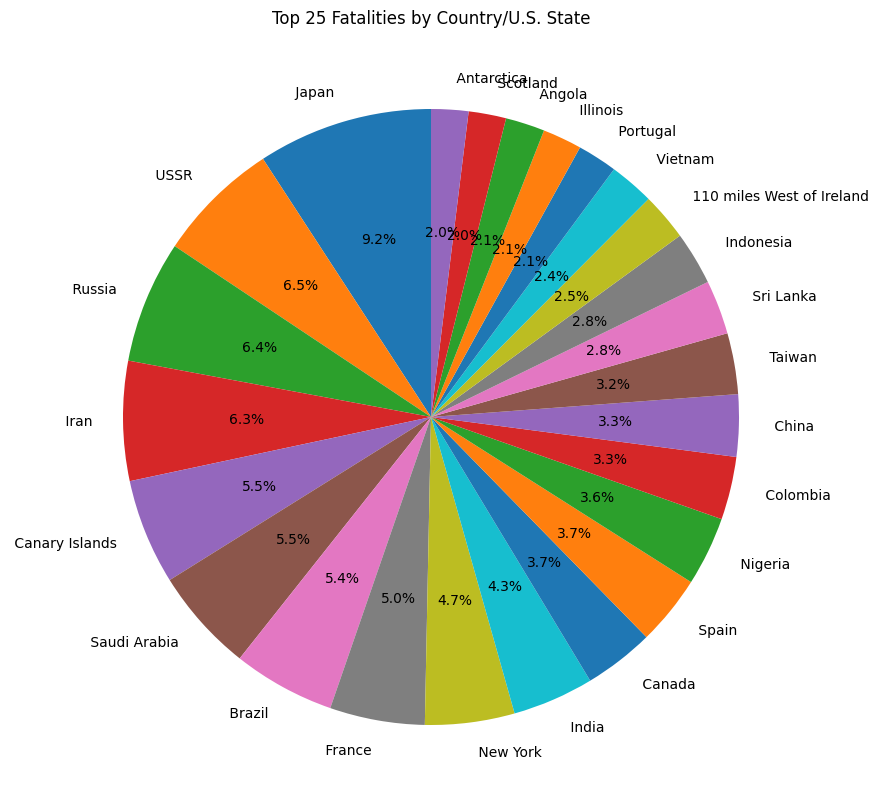

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

top25 = (
    top_100_fatalities
    .groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(10,10))
plt.pie(
    top25,
    labels=top25.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top 25 Fatalities by Country/U.S. State')
plt.show()